In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_theme(style="darkgrid", palette="muted")
FRAUD_COLOR   = "#e74c3c"
NORMAL_COLOR  = "#2ecc71"
ACCENT_COLOR  = "#3498db"

In [6]:
DATA_PATH = '../Dataset/fraud_data.csv'
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (6362620, 11)


In [7]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None) 

In [8]:
print(df.head())
print(df.dtypes)

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
step                int64
type               object
amount            float64
nameOrig           object
o

In [9]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [11]:
print(df.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%      0.000000e+00    0.000000e+00

In [10]:
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


### Class Imbalance

In [13]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct    = fraud_counts / len(df) * 100

print(f"  Legitimate : {fraud_counts[0]:>10,}  ({fraud_pct[0]:.4f}%)")
print(f"  Fraud      : {fraud_counts[1]:>10,}  ({fraud_pct[1]:.4f}%)")

  Legitimate :  6,354,407  (99.8709%)
  Fraud      :      8,213  (0.1291%)


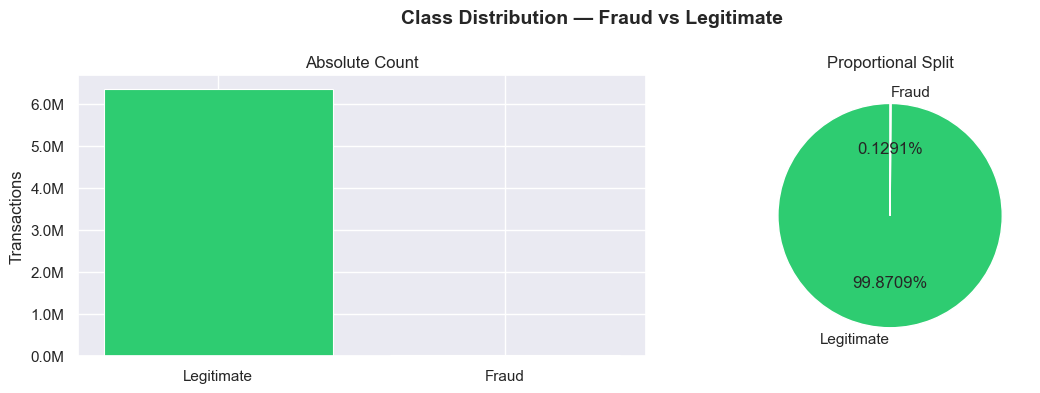

  Saved → plot_01_class_imbalance.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution — Fraud vs Legitimate", fontsize=14, fontweight="bold")
axes[0].bar(["Legitimate", "Fraud"], fraud_counts.values,
            color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor="white", linewidth=0.8)
axes[0].set_title("Absolute Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].set_ylabel("Transactions")

axes[1].pie(fraud_counts.values, labels=["Legitimate", "Fraud"],
            colors=[NORMAL_COLOR, FRAUD_COLOR], autopct="%1.4f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proportional Split")

plt.tight_layout()
plt.savefig("plot_01_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_01_class_imbalance.png")

### Transaction Types BreakDown

          fraud_count    total  fraud_rate
type                                      
CASH_OUT         4116  2237500    0.183955
PAYMENT             0  2151495    0.000000
CASH_IN             0  1399284    0.000000
TRANSFER         4097   532909    0.768799
DEBIT               0    41432    0.000000


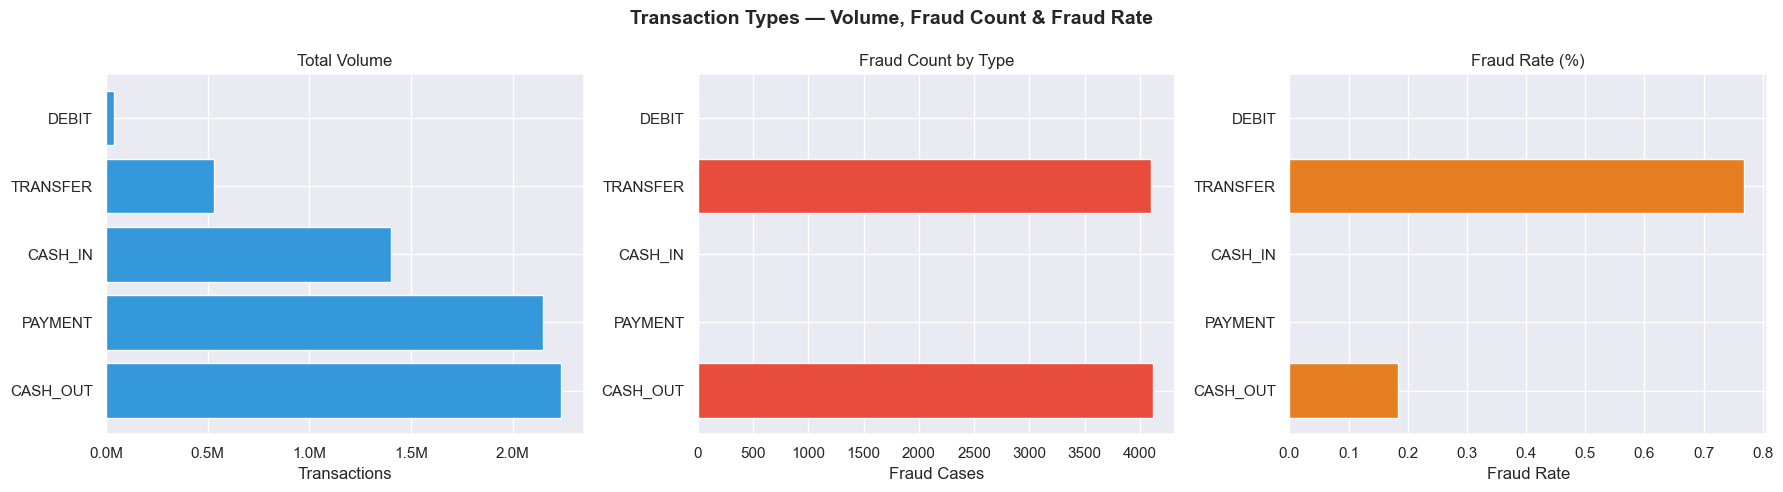

  Saved → plot_02_transaction_types.png


In [23]:
type_fraud = df.groupby("type")["isFraud"].agg(["sum", "count"])
type_fraud["fraud_rate"] = type_fraud["sum"] / type_fraud["count"] * 100
type_fraud = type_fraud.sort_values("count", ascending=False)

print(type_fraud.rename(columns={"sum": "fraud_count", "count": "total"}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Transaction Types — Volume, Fraud Count & Fraud Rate", fontsize=14, fontweight="bold")

axes[0].barh(type_fraud.index, type_fraud["count"],
             color=ACCENT_COLOR, edgecolor="white")
axes[0].set_title("Total Volume")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].set_xlabel("Transactions")

axes[1].barh(type_fraud.index, type_fraud["sum"],
             color=FRAUD_COLOR, edgecolor="white")
axes[1].set_title("Fraud Count by Type")
axes[1].set_xlabel("Fraud Cases")

axes[2].barh(type_fraud.index, type_fraud["fraud_rate"],
             color="#e67e22", edgecolor="white")
axes[2].set_title("Fraud Rate (%)")
axes[2].set_xlabel("Fraud Rate")

plt.tight_layout()
plt.savefig("plot_02_transaction_types.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_02_transaction_types.png")

The third chart is the most important insight. A TRANSFER has a 76.8% chance of being fraud

### Transaction Amount Disctribution

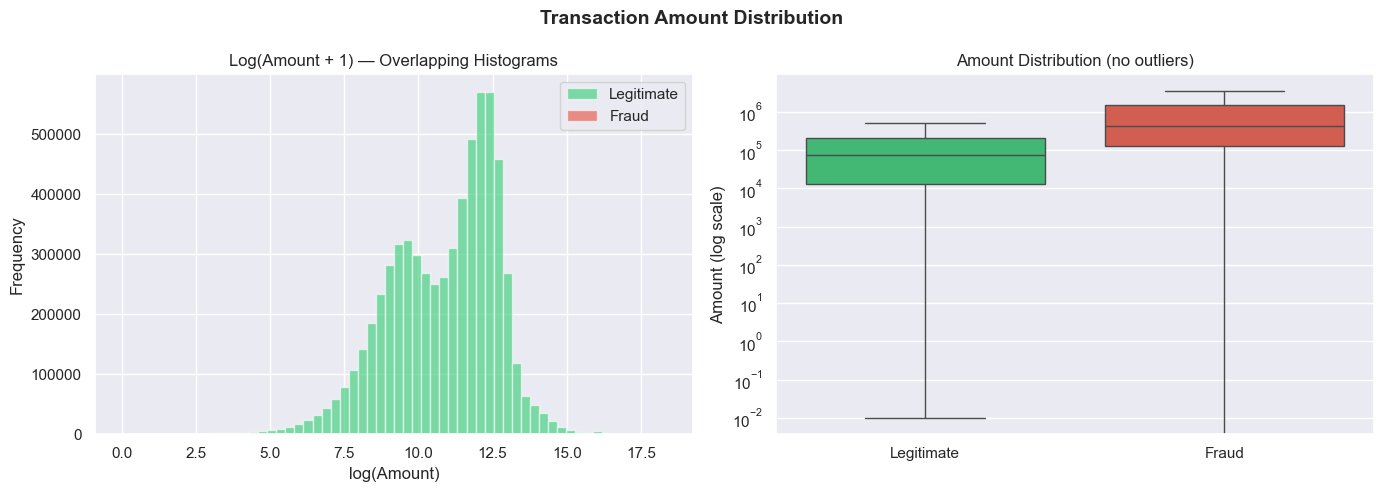

  Saved → plot_03_amount_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Amount Distribution", fontsize=14, fontweight="bold")

# Log-scale histogram
for label, color in [(0, NORMAL_COLOR), (1, FRAUD_COLOR)]:
    subset = df[df["isFraud"] == label]["amount"]
    axes[0].hist(np.log1p(subset), bins=60, alpha=0.6,
                 color=color, label=["Legitimate", "Fraud"][label])
axes[0].set_title("Log(Amount + 1) — Overlapping Histograms")
axes[0].set_xlabel("log(Amount)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
df_plot = df[["amount", "isFraud"]].copy()
df_plot["label"] = df_plot["isFraud"].map({0: "Legitimate", 1: "Fraud"})
sns.boxplot(data=df_plot, x="label", y="amount", palette=[NORMAL_COLOR, FRAUD_COLOR],
            showfliers=False, ax=axes[1])
axes[1].set_title("Amount Distribution (no outliers)")
axes[1].set_yscale("log")
axes[1].set_ylabel("Amount (log scale)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("plot_03_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_03_amount_distribution.png")

### Balance Mismatch Analysis


  Legitimate:
    Orig mismatch mean :     -201,338.56
    Dest mismatch mean :       54,692.23

  Fraud:
    Orig mismatch mean :      -10,692.33
    Dest mismatch mean :      732,509.30


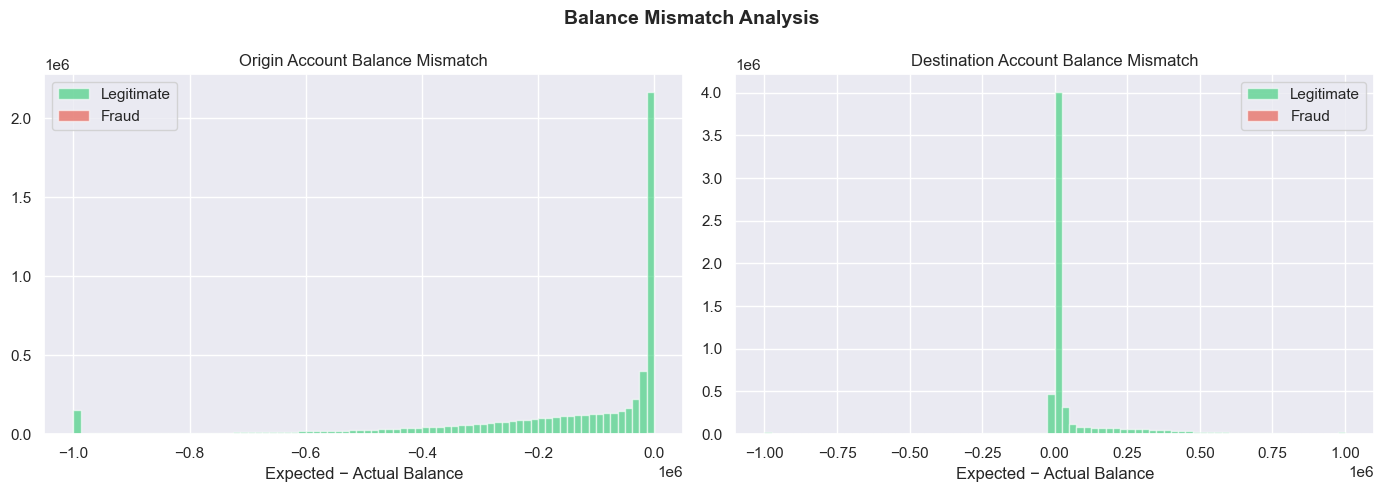

  Saved → plot_04_balance_mismatch.png


In [25]:
# A genuine transfer should satisfy: newbalanceOrig = oldbalanceOrg - amount
df["orig_balance_diff"] = (df["oldbalanceOrg"] - df["amount"]) - df["newbalanceOrig"]
df["dest_balance_diff"] = (df["oldbalanceDest"] + df["amount"]) - df["newbalanceDest"]

for label, name in [(0, "Legitimate"), (1, "Fraud")]:
    sub = df[df["isFraud"] == label]
    print(f"\n  {name}:")
    print(f"    Orig mismatch mean : {sub['orig_balance_diff'].mean():>15,.2f}")
    print(f"    Dest mismatch mean : {sub['dest_balance_diff'].mean():>15,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Balance Mismatch Analysis", fontsize=14, fontweight="bold")

for i, (col, title) in enumerate([
    ("orig_balance_diff", "Origin Account Balance Mismatch"),
    ("dest_balance_diff", "Destination Account Balance Mismatch")
]):
    for label, color in [(0, NORMAL_COLOR), (1, FRAUD_COLOR)]:
        subset = df[df["isFraud"] == label][col].clip(-1e6, 1e6)
        axes[i].hist(subset, bins=80, alpha=0.6,
                     color=color, label=["Legitimate", "Fraud"][label])
    axes[i].set_title(title)
    axes[i].set_xlabel("Expected − Actual Balance")
    axes[i].legend()

plt.tight_layout()
plt.savefig("plot_04_balance_mismatch.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_04_balance_mismatch.png")

### Correlation Heatmap

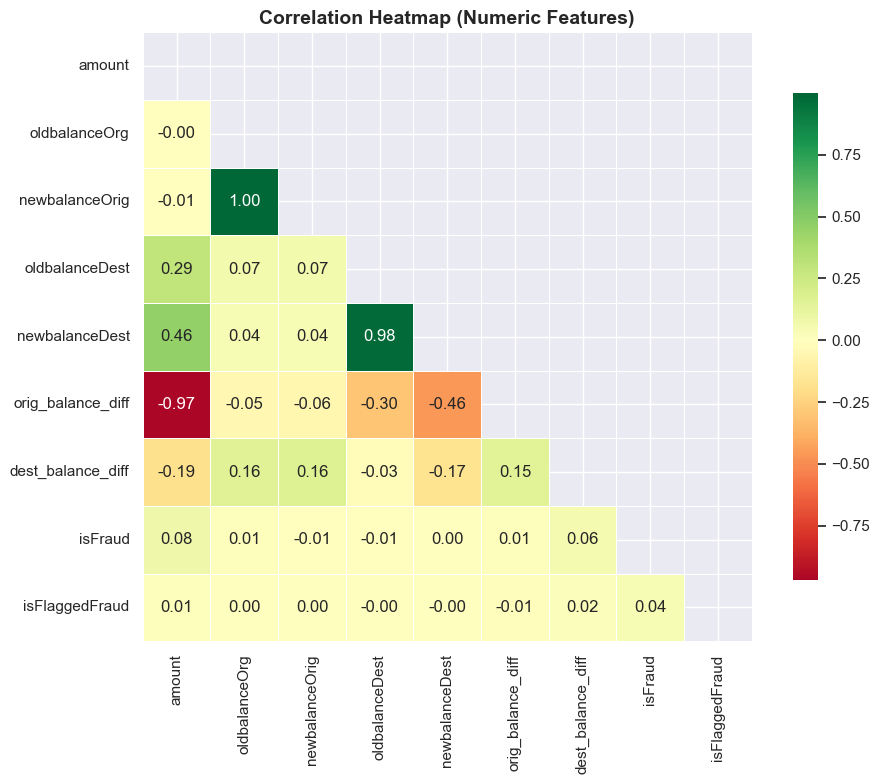

  Saved → plot_05_correlation_heatmap.png


In [26]:
num_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest",
            "orig_balance_diff", "dest_balance_diff",
            "isFraud", "isFlaggedFraud"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap (Numeric Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_05_correlation_heatmap.png")


### Flagged Fraud vs Actual Fraud


  Total fraud cases   : 8,213
  Flagged by system   : 16
  Correctly caught    : 16  (0.19% recall)
  Missed (false neg)  : 8,197
  False alarms        : 0


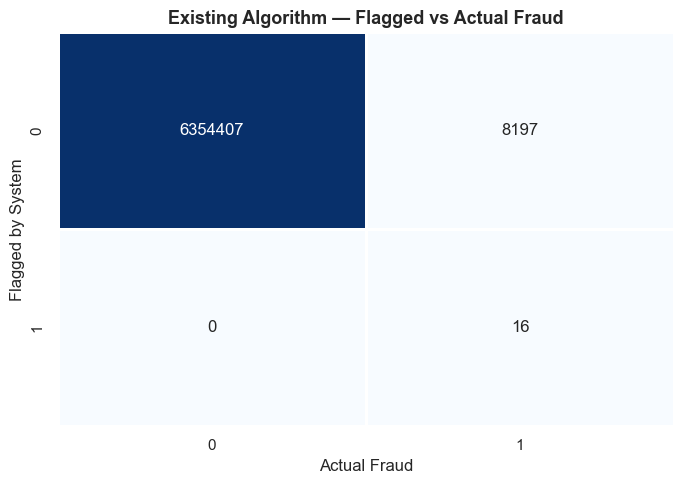

  Saved → plot_06_flag_vs_actual.png


In [27]:
flag_matrix = pd.crosstab(df["isFlaggedFraud"], df["isFraud"],
                          rownames=["Flagged"], colnames=["Actual"])

total_fraud    = df["isFraud"].sum()
total_flagged  = df["isFlaggedFraud"].sum()
caught         = df[(df["isFlaggedFraud"] == 1) & (df["isFraud"] == 1)].shape[0]
missed         = total_fraud - caught
false_alarms   = total_flagged - caught

print(f"\n  Total fraud cases   : {total_fraud:,}")
print(f"  Flagged by system   : {total_flagged:,}")
print(f"  Correctly caught    : {caught:,}  ({caught/total_fraud*100:.2f}% recall)")
print(f"  Missed (false neg)  : {missed:,}")
print(f"  False alarms        : {false_alarms:,}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(flag_matrix, annot=True, fmt="d", cmap="Blues",
            linewidths=1, ax=ax, cbar=False)
ax.set_title("Existing Algorithm — Flagged vs Actual Fraud", fontsize=13, fontweight="bold")
ax.set_xlabel("Actual Fraud")
ax.set_ylabel("Flagged by System")
plt.tight_layout()
plt.savefig("plot_06_flag_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_06_flag_vs_actual.png")

### Fraud By step ( time proxy)

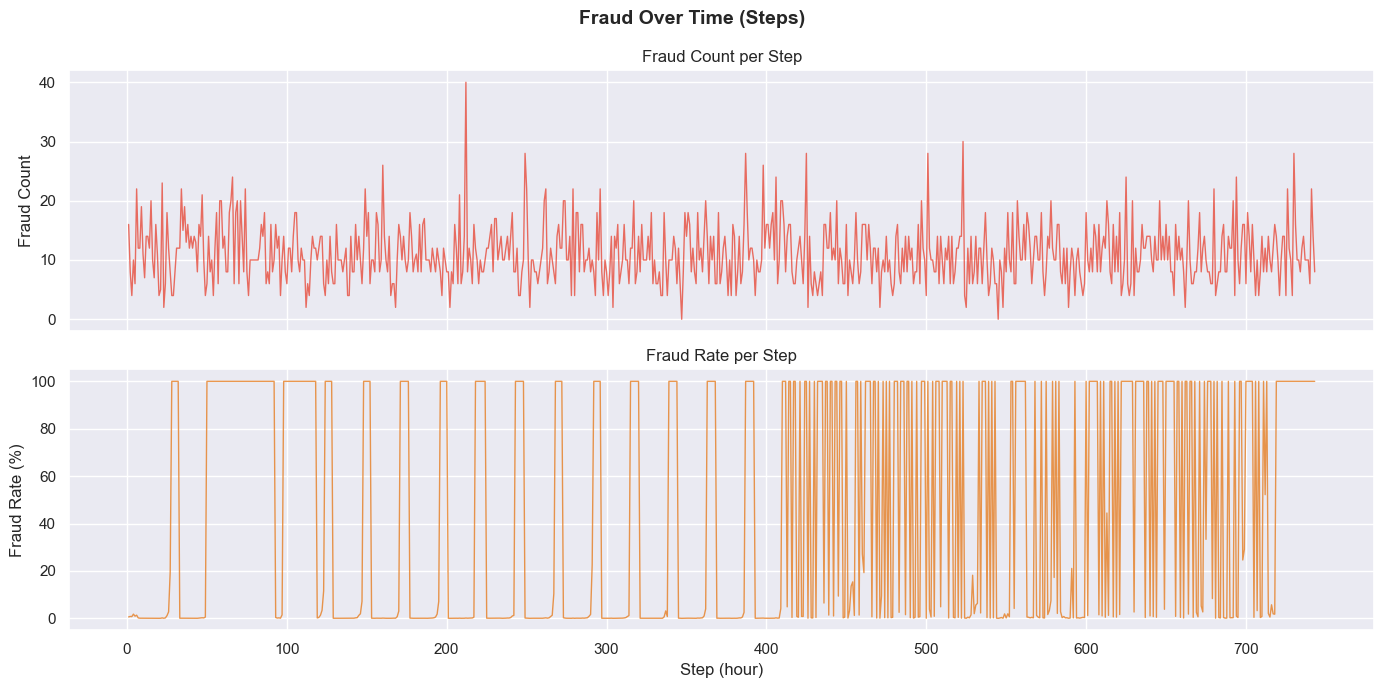

  Saved → plot_07_fraud_over_time.png


In [28]:
step_fraud = df.groupby("step")["isFraud"].agg(["mean", "sum"]).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Fraud Over Time (Steps)", fontsize=14, fontweight="bold")

axes[0].plot(step_fraud["step"], step_fraud["sum"],
             color=FRAUD_COLOR, linewidth=1, alpha=0.8)
axes[0].set_ylabel("Fraud Count")
axes[0].set_title("Fraud Count per Step")

axes[1].plot(step_fraud["step"], step_fraud["mean"] * 100,
             color="#e67e22", linewidth=1, alpha=0.8)
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("Step (hour)")
axes[1].set_title("Fraud Rate per Step")

plt.tight_layout()
plt.savefig("plot_07_fraud_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → plot_07_fraud_over_time.png")